# BetaGDD — AlphaEarth location context (per species)

Tests whether site-level AlphaEarth satellite embeddings improve BetaGDD
generalisation to **held-out locations**, run **separately per species**.

Pooling across species was incorrect: AEE embeddings are location-based and
carry no species signal, so a pooled model cannot distinguish Apple from Plum.

Models compared (per species):

| Model | Context | Generalises to held-out locs? |
|---|---|---|
| `GlobalBetaGDD` | none | yes |
| `AlphaEarthBetaGDD` + ridge | static site embedding | yes |
| `GlobalBetaGDD` per-location | none | no (in-sample ceiling) |

## Setup

In [16]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

from pysephone.constants import KEY_DATA_SOURCE, KEY_FEATURES, KEY_LOC_ID
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.observations import Observations
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.dataset.util.provider import FeatureProvider
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.beta_gdd import GlobalBetaGDDModel, AlphaEarthBetaGDDModel

DATASETS_CONFIG = {
    'Apple':   dict(key='PEP725_Apple',   obs_key='BBCH_60'),
    'Pear':    dict(key='PEP725_Pear',    obs_key='BBCH_60'),
    'Peach':   dict(key='PEP725_Peach',   obs_key='BBCH_60'),
    'Almond':  dict(key='PEP725_Almond',  obs_key='BBCH_60'),
    'Cherry':  dict(key='PEP725_Cherry',  obs_key='BBCH_60'),
    'Apricot': dict(key='PEP725_Apricot', obs_key='BBCH_60'),
    'Plum':    dict(key='PEP725_Plum',    obs_key='BBCH_60'),
}

CUTOFF           = 2010
LOC_HOLDOUT_FRAC = 0.2
RANDOM_SEED      = 42
FIT_PER_LOCATION = True
CTX_RIDGE_LAMBDA = 1e-3
MIN_TEST_SAMPLES = 5   # min test samples required to include a location in per-loc evaluation
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

GLOBAL_MODEL_KWARGS = dict(
    t_low=1.4, t_high=15.9, learn_bounds=False,
    alpha_init=2.0, beta_init=2.0, learn_alpha_beta=True,
    learn_t_base=False, t_base_init=5.0, learn_thresholds=True,
)
CTX_MODEL_KWARGS = dict(
    t_low=1.4, t_high=15.9,
    learn_t_base=False, t_base_init=5.0, learn_thresholds=True,
    ctx_reg_lambda=CTX_RIDGE_LAMBDA,
)
FIT_KWARGS = dict(
    num_epochs=1000, batch_size=512, val_period=10,
    optimizer='adam', optimizer_kwargs=dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size=100, scheduler_decay=0.9,
    early_stopping=True, early_stopping_patience=10,
    early_stopping_min_delta=1e-4, device=DEVICE, verbose=False,
)

cal        = Calendar(default_start='10-01', default_length=365)
temp_cache = FeatureCache.load(FeatureCache.default_path('PEP725_fruit_trees', ['temperature_2m_mean']))
print('Device:', DEVICE)

Device: cuda


## AlphaEarth helpers

`compute_static_aee` averages all available AEE years (2017+) for each site —
entirely outside the PEP725 training window — producing a static habitat descriptor.

In [17]:
from pysephone.data.alphaearth.obtain_embeddings import (
    AlphaEarthEmbeddingStore, _stable_location_id, EMBED_DIM,
)

store = AlphaEarthEmbeddingStore()


def compute_static_aee(observations, precision=6):
    """Return {(src, loc_id): mean_embedding} averaged over ALL available AEE years."""
    unique_locs = set((ix[0], ix[1]) for ix in observations.iter_index())
    result      = {}
    n_missing   = 0
    for src, loc_id in tqdm(unique_locs, desc='Computing static AEE', leave=False):
        coords    = observations.get_location_coordinates((src, loc_id))
        alpha_loc = _stable_location_id(coords['lat'], coords['lon'], precision=precision)
        with store._open('r') as f:
            path = f'v1/locations/{alpha_loc}/embeddings'
            if path not in f:
                result[(src, loc_id)] = np.zeros(EMBED_DIM, dtype=np.float32)
                n_missing += 1
                continue
            vecs = [np.array(f[path][yr][...], dtype=np.float32) for yr in f[path]]
        if vecs:
            result[(src, loc_id)] = np.stack(vecs).mean(axis=0)
        else:
            result[(src, loc_id)] = np.zeros(EMBED_DIM, dtype=np.float32)
            n_missing += 1
    print(f'  AEE: {n_missing}/{len(unique_locs)} locations with no coverage (zeroed)')
    return result


class StaticAEEFeatures(FeatureProvider):
    KEY = 'alphaearth_embedding'

    def __init__(self, loc_emb_map: dict):
        self._map = loc_emb_map

    def get_data(self, index):
        src, loc_id = index[0], index[1]
        vec = self._map.get((src, loc_id), np.zeros(EMBED_DIM, dtype=np.float32))
        return {self.KEY: vec.copy()}

## Per-species analysis loop

For each species independently:
1. Random 80/20 location holdout split
2. Compute static AEE per site
3. Fit global model, AEE contextual model, per-location models
4. Evaluate on seen-test and holdout splits
5. Extract per-location α/β from the contextual model

In [18]:
results = {}

for label, cfg in DATASETS_CONFIG.items():
    print(f'\n{"="*60}\n  {label}\n{"="*60}')
    obs_key   = cfg['obs_key']
    target_fn = lambda s, k=obs_key: s['observations'][k]

    # Load dataset
    ds = Dataset.load(cfg['key'], calendar=cal, feature_providers=[temp_cache])

    # Location split
    all_locs     = sorted(ds.locations)
    rng          = np.random.default_rng(RANDOM_SEED)
    rng.shuffle(all_locs)
    n_holdout    = max(1, int(len(all_locs) * LOC_HOLDOUT_FRAC))
    locs_holdout = all_locs[:n_holdout]
    locs_train   = all_locs[n_holdout:]

    ds_seen    = ds.select_locations(locs_train)
    ds_holdout = ds.select_locations(locs_holdout)
    ds_seen_trn = ds_seen.select_years([y for y in sorted(ds_seen.years)   if y <  CUTOFF])
    ds_seen_tst = ds_seen.select_years([y for y in sorted(ds_seen.years)   if y >= CUTOFF])
    print(f'  Locs: {len(locs_train)} train / {len(locs_holdout)} holdout')
    print(f'  Samples: {len(ds_seen_trn)} trn  {len(ds_seen_tst)} seen_tst  {len(ds_holdout)} holdout')

    # Static AEE
    static_aee   = compute_static_aee(ds._obs)
    aee_provider = StaticAEEFeatures(static_aee)
    trn_vecs = np.stack([static_aee[(s, l)] for s, l in locs_train if (s, l) in static_aee])
    ae_mean  = trn_vecs.mean(0)
    ae_std   = trn_vecs.std(0);  ae_std[ae_std < 1e-8] = 1.0

    def _with_aee(src_obs):
        return Dataset(src_obs, calendar=cal, feature_providers=[temp_cache, aee_provider])

    ds_seen_trn_aee = _with_aee(ds_seen_trn._obs)
    ds_seen_tst_aee = _with_aee(ds_seen_tst._obs)
    ds_hold_tst_aee = _with_aee(ds_holdout._obs)

    # Fit global model
    model_global, _ = GlobalBetaGDDModel.fit(
        target_fn=target_fn, dataset=ds_seen_trn,
        model_kwargs=GLOBAL_MODEL_KWARGS, **FIT_KWARGS,
    )
    print(f'  Global  α={model_global.alpha.item():.3f}  β={model_global.beta.item():.3f}')

    # Fit AEE contextual model
    model_aee, _ = AlphaEarthBetaGDDModel.fit(
        target_fn=target_fn, dataset=ds_seen_trn_aee,
        model_kwargs=dict(CTX_MODEL_KWARGS, ae_mean=ae_mean, ae_std=ae_std, ctx_hidden=32),
        **FIT_KWARGS,
    )
    print(f'  AEE fitted.')

    # Per-location models (in-sample ceiling)
    per_loc_models = {}
    if FIT_PER_LOCATION:
        pl_kwargs = dict(FIT_KWARGS, num_epochs=300, early_stopping=False)
        for loc in tqdm(locs_train, desc=f'  Per-loc {label}', leave=False):
            ds_loc = ds_seen_trn.select_locations([loc])
            if len(ds_loc) < 5:
                continue
            m, _ = GlobalBetaGDDModel.fit(
                target_fn=target_fn, dataset=ds_loc,
                model_kwargs=GLOBAL_MODEL_KWARGS, **pl_kwargs,
            )
            per_loc_models[loc] = m

    # Evaluation helper (suppress SmallSampleWarning from tiny per-loc test sets)
    def _metrics(model, trn, tst, t_fn, name):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            res = SingleTargetRegression.run(
                model=model, dataset_train=trn, dataset_test=tst,
                target_fn=t_fn, run_name=name,
            )
        return res.compute_metrics()['test']

    metrics = {
        'global_seen':    _metrics(model_global, ds_seen_trn,     ds_seen_tst,     target_fn, 'gs'),
        'global_holdout': _metrics(model_global, ds_seen_trn,     ds_holdout,      target_fn, 'gh'),
        'aee_seen':       _metrics(model_aee,    ds_seen_trn_aee, ds_seen_tst_aee, target_fn, 'as'),
        'aee_holdout':    _metrics(model_aee,    ds_seen_trn_aee, ds_hold_tst_aee, target_fn, 'ah'),
    }

    per_loc_rows = []
    for loc, m in per_loc_models.items():
        ds_loc_tst = ds_seen_tst.select_locations([loc])
        if len(ds_loc_tst) < MIN_TEST_SAMPLES:
            continue
        met = _metrics(m, ds_seen_trn.select_locations([loc]), ds_loc_tst, target_fn, 'pl')
        per_loc_rows.append(met)

    # Extract α/β from AEE model across all locations
    model_aee.eval()
    aee_ab = {}
    with torch.no_grad():
        for loc in locs_train + locs_holdout:
            src, loc_id = loc
            vec = static_aee.get((src, loc_id), np.zeros(EMBED_DIM, dtype=np.float32))
            emb = torch.tensor(vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            xs  = {
                KEY_DATA_SOURCE: [src],
                KEY_LOC_ID:      [loc_id],
                KEY_FEATURES:    {StaticAEEFeatures.KEY: emb},
            }
            cf = model_aee.get_cf_parameters(xs)
            aee_ab[loc] = {'alpha': cf['alpha'].item(), 'beta': cf['beta'].item()}

    alphas = np.array([v['alpha'] for v in aee_ab.values()])
    betas  = np.array([v['beta']  for v in aee_ab.values()])
    print(f'  α: mean={alphas.mean():.3f}  std={alphas.std():.4f}  range=[{alphas.min():.3f}, {alphas.max():.3f}]')
    print(f'  β: mean={betas.mean():.3f}  std={betas.std():.4f}  range=[{betas.min():.3f}, {betas.max():.3f}]')
    print(f'  Global:  seen={metrics["global_seen"]["mae"]:.1f}d  holdout={metrics["global_holdout"]["mae"]:.1f}d')
    print(f'  AEE:     seen={metrics["aee_seen"]["mae"]:.1f}d  holdout={metrics["aee_holdout"]["mae"]:.1f}d')
    if per_loc_rows:
        print(f'  Per-loc: mean={np.mean([r["mae"] for r in per_loc_rows]):.1f}d  '
              f'(n={len(per_loc_rows)} locs with ≥{MIN_TEST_SAMPLES} test samples)')

    results[label] = dict(
        model_global=model_global, model_aee=model_aee,
        per_loc_models=per_loc_models, per_loc_rows=per_loc_rows,
        metrics=metrics, aee_ab=aee_ab, static_aee=static_aee,
        locs_train=locs_train, locs_holdout=locs_holdout,
    )

print('\nAll species done.')


  Apple


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 46334.13it/s]


  Locs: 669 train / 167 holdout
  Samples: 4215 trn  1255 seen_tst  1291 holdout


Computing static AEE:   0%|          | 0/836 [00:00<?, ?it/s]

  AEE: 0/836 locations with no coverage (zeroed)
  Global  α=1.607  β=2.855
  AEE fitted.


...

  Locs: 498 train / 124 holdout
  Samples: 2193 trn  320 seen_tst  591 holdout


Computing static AEE:   0%|          | 0/622 [00:00<?, ?it/s]

  AEE: 0/622 locations with no coverage (zeroed)
  Global  α=1.807  β=2.811
  AEE fitted.


  Per-loc Plum:   0%|          | 0/498 [00:00<?, ?it/s]

  α: mean=1.269  std=0.1888  range=[1.005, 2.109]
  β: mean=2.033  std=0.5632  range=[1.015, 3.080]
  Global:  seen=10.0d  holdout=8.2d
  AEE:     seen=9.9d  holdout=7.6d
  Per-loc: mean=10.5d  (n=13 locs with ≥5 test samples)

All species done.


## Results

In [19]:
rows = []
for label, r in results.items():
    m      = r['metrics']
    alphas = np.array([v['alpha'] for v in r['aee_ab'].values()])
    betas  = np.array([v['beta']  for v in r['aee_ab'].values()])
    pl_mae = np.mean([x['mae'] for x in r['per_loc_rows']]) if r['per_loc_rows'] else float('nan')
    rows.append(dict(
        species        = label,
        n_locs         = len(r['locs_train']) + len(r['locs_holdout']),
        n_pl_eval      = len(r['per_loc_rows']),
        global_seen    = m['global_seen']['mae'],
        aee_seen       = m['aee_seen']['mae'],
        global_holdout = m['global_holdout']['mae'],
        aee_holdout    = m['aee_holdout']['mae'],
        per_loc_mae    = pl_mae,
        g_alpha        = r['model_global'].alpha.item(),
        g_beta         = r['model_global'].beta.item(),
        aee_alpha_std  = alphas.std(),
        aee_beta_std   = betas.std(),
    ))

df = pd.DataFrame(rows).set_index('species').round(3)

print('── MAE (days) ─────────────────────────────────────────────────────────────')
print(df[['n_locs', 'global_seen', 'aee_seen', 'global_holdout', 'aee_holdout', 'per_loc_mae', 'n_pl_eval']].to_string())
print()
print('── Global α/β + AEE spread across locations ───────────────────────────────')
print(df[['g_alpha', 'g_beta', 'aee_alpha_std', 'aee_beta_std']].to_string())

── MAE (days) ─────────────────────────────────────────────────────────────
         n_locs  global_seen  aee_seen  global_holdout  aee_holdout  per_loc_mae  n_pl_eval
species                                                                                    
Apple       836        5.601     5.169           6.207        5.963        6.719        106
Pear        590        6.700     6.135           6.939        6.386       10.480         58
Peach       391       11.100    16.800           6.204        5.723          NaN          0
Almond       20       14.486    24.946          17.000       11.250       30.389          3
Cherry     1095        7.276     6.597           7.345        7.087       12.177         92
Apricot      70       23.592    11.056          18.316       16.868          NaN          0
Plum        622       10.022     9.891           8.162        7.552       10.547         13

── Global α/β + AEE spread across locations ───────────────────────────────
         g_alpha  g

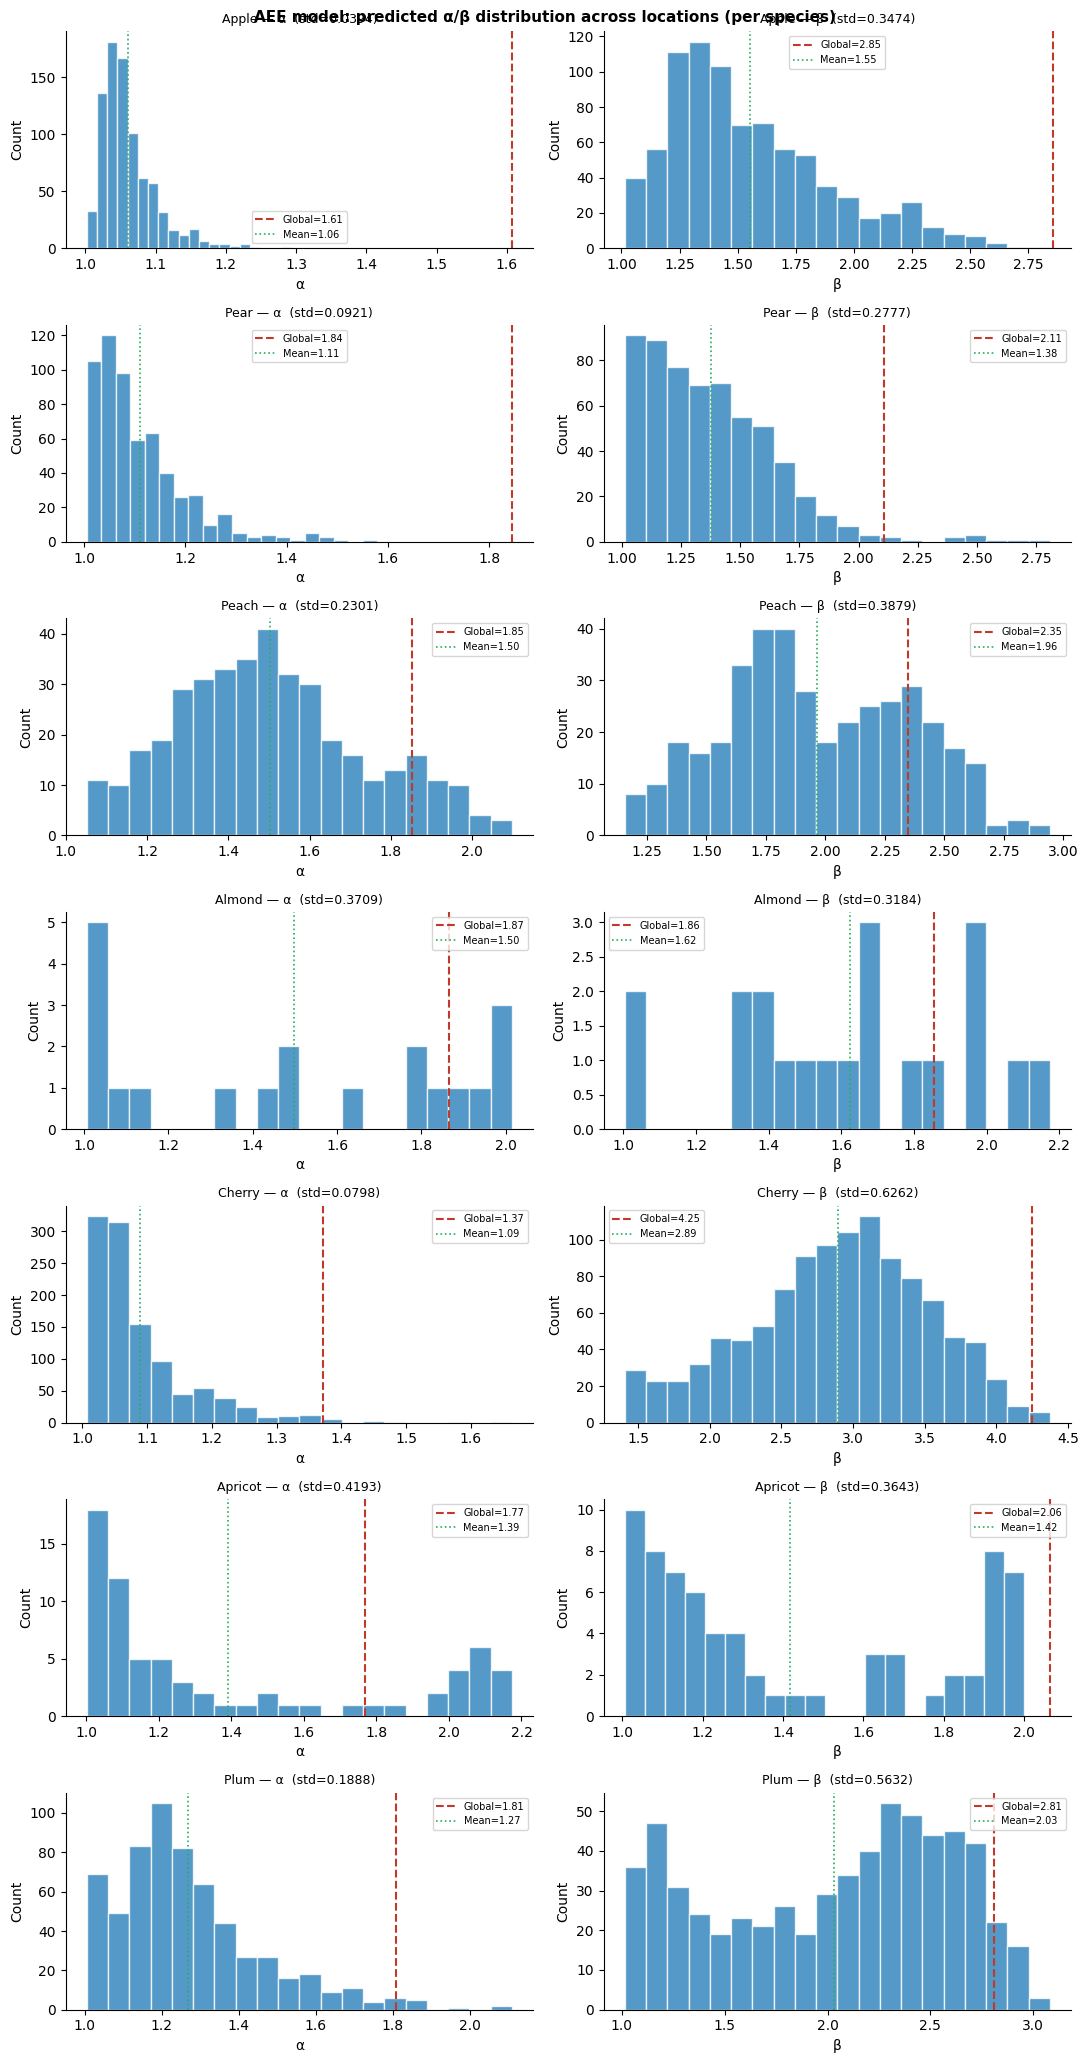

In [20]:
n_sp = len(results)
fig, axes = plt.subplots(n_sp, 2, figsize=(11, 3 * n_sp), squeeze=False)
fig.suptitle('AEE model: predicted α/β distribution across locations (per species)',
             fontsize=11, fontweight='bold')

for row_i, (label, r) in enumerate(results.items()):
    alphas  = np.array([v['alpha'] for v in r['aee_ab'].values()])
    betas   = np.array([v['beta']  for v in r['aee_ab'].values()])
    g_alpha = r['model_global'].alpha.item()
    g_beta  = r['model_global'].beta.item()

    for col_i, (vals, param, gval) in enumerate([
        (alphas, 'α', g_alpha),
        (betas,  'β', g_beta),
    ]):
        ax = axes[row_i, col_i]
        ax.hist(vals, bins=20, color='#2980b9', alpha=0.8, edgecolor='white')
        ax.axvline(gval,        color='#c0392b', lw=1.5, ls='--', label=f'Global={gval:.2f}')
        ax.axvline(vals.mean(), color='#27ae60', lw=1.2, ls=':',  label=f'Mean={vals.mean():.2f}')
        ax.set_title(f'{label} — {param}  (std={vals.std():.4f})', fontsize=9)
        ax.set_xlabel(param)
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

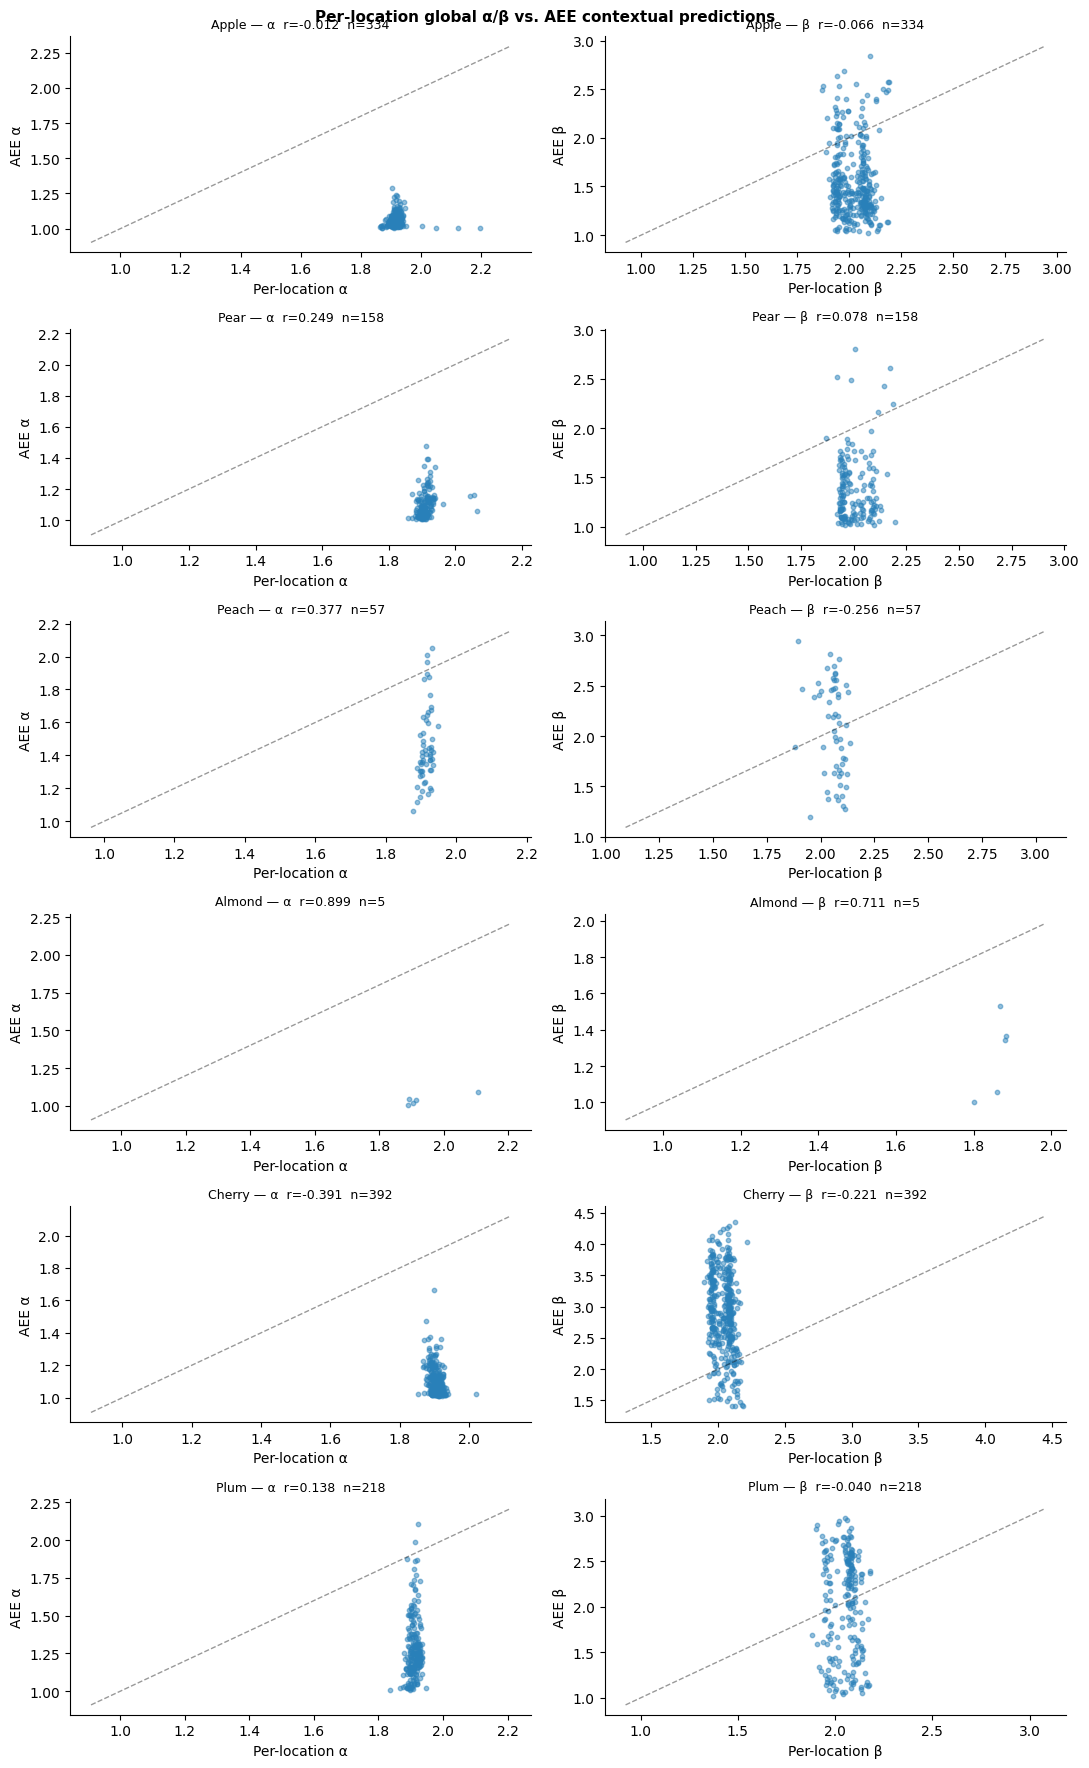

High r: AEE predictions agree with per-location fits.
Low r:  AEE learns a different (possibly smoother) signal, or per-loc fits are noisy.


In [21]:
if FIT_PER_LOCATION:
    sp_with_pl = [(l, r) for l, r in results.items() if r['per_loc_models']]
    n_sp = len(sp_with_pl)
    if n_sp > 0:
        fig, axes = plt.subplots(n_sp, 2, figsize=(11, 3 * n_sp), squeeze=False)
        fig.suptitle('Per-location global α/β vs. AEE contextual predictions',
                     fontsize=11, fontweight='bold')

        for row_i, (label, r) in enumerate(sp_with_pl):
            common = [l for l in r['locs_train']
                      if l in r['per_loc_models'] and l in r['aee_ab']]
            pl_a = np.array([r['per_loc_models'][l].alpha.item() for l in common])
            pl_b = np.array([r['per_loc_models'][l].beta.item()  for l in common])
            ae_a = np.array([r['aee_ab'][l]['alpha']              for l in common])
            ae_b = np.array([r['aee_ab'][l]['beta']               for l in common])

            for col_i, (pl_v, ae_v, param) in enumerate([
                (pl_a, ae_a, 'α'),
                (pl_b, ae_b, 'β'),
            ]):
                ax = axes[row_i, col_i]
                ax.scatter(pl_v, ae_v, s=10, alpha=0.5, color='#2980b9')
                lim = [min(pl_v.min(), ae_v.min()) - 0.1,
                       max(pl_v.max(), ae_v.max()) + 0.1]
                ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
                corr = np.corrcoef(pl_v, ae_v)[0, 1] if len(pl_v) > 1 else float('nan')
                ax.set_title(f'{label} — {param}  r={corr:.3f}  n={len(common)}', fontsize=9)
                ax.set_xlabel(f'Per-location {param}')
                ax.set_ylabel(f'AEE {param}')
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()
        print('High r: AEE predictions agree with per-location fits.')
        print('Low r:  AEE learns a different (possibly smoother) signal, or per-loc fits are noisy.')